# Fast-VTON — Stage 1 trên Colab A100

Notebook này **chỉ điều phối**: mọi logic nằm trong `src/`, ở đây chỉ gọi.
Đọc `docs/VTON_PLAN.md` để hiểu vì sao mỗi bước lại như vậy.

**Luồng chạy**

| Bước | Việc | Thời gian |
|---|---|---|
| 1–3 | Môi trường, repo, checkpoint | ~25 phút |
| 4 | Dữ liệu VITON-HD + **cổng chặn: kiểm tra mask** | ~20 phút |
| 5 | Embedding rỗng cho F_θ | ~2 phút |
| 6 | **Cổng chặn: overfit 8 mẫu** | ~10 phút |
| 7 | Cache đầy đủ 11,647 mẫu | ~30 phút |
| 8 | Train Stage 1 | nhiều giờ |
| 9 | Đóng gói 1 file → Google Drive | ~5 phút |

Hai cổng chặn có dấu ⛔ — sai ở đó thì mọi thứ phía sau vô nghĩa, **đừng chạy tiếp**.

> **Runtime.** Hai cổng chặn (bước 4 và 6) chạy tốt trên **T4** — dùng nó để soát đường ống
> cho rẻ. Chỉ bước 7–8 mới cần **A100**.
>
> Độ chính xác tự chọn theo GPU: `--mixed-precision auto` lấy **bf16** trên Ampere trở lên,
> **fp16** trên card cũ hơn. T4 là compute capability 7.5, **không có bf16** — ép bf16 ở đó
> thì `torch.autocast` chỉ báo lỗi ở step đầu tiên, sau khi đã nạp xong trọng số.
>
> Batch size tự dò theo VRAM ở bước 8. A100 Colab Pro thường là 40 GB; bản 80 GB không
> đảm bảo.

## 1. Kiểm tra GPU

In [1]:
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv

name, memory.total [MiB], memory.used [MiB]
NVIDIA A100-SXM4-80GB, 81920 MiB, 0 MiB


## 2. Cài môi trường và lấy code

Mặc định clone từ `REPO_URL` — **nhớ push commit mới nhất lên GitHub trước khi chạy**,
Colab lấy đúng những gì có trên remote.

Muốn chạy code chưa push thì đặt `USE_DRIVE_COPY = True` và copy thư mục repo lên Drive
tại đúng `DRIVE_REPO_PATH`.

In [2]:
# Mount Google Drive to access the dataset and save checkpoints
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
REPO_URL = "https://github.com/hoangtung386/Fast-VTON.git"
USE_DRIVE_COPY = False                                 # True = copy từ Drive thay vì clone
DRIVE_REPO_PATH = "/content/drive/MyDrive/Fast-VTON"   # chỉ dùng khi USE_DRIVE_COPY = True

In [4]:
import shutil
from pathlib import Path

PROJECT = Path("/content/Fast-VTON")

# copytree ném FileNotFoundError trần trụi nếu nguồn không có — báo rõ nguyên nhân trước.
if USE_DRIVE_COPY and not Path(DRIVE_REPO_PATH).is_dir():
    raise FileNotFoundError(
        f"không thấy {DRIVE_REPO_PATH} trên Drive.\n"
        f"Đặt USE_DRIVE_COPY = False để clone từ {REPO_URL}, "
        "hoặc sửa DRIVE_REPO_PATH cho đúng thư mục thật."
    )

if PROJECT.exists():
    shutil.rmtree(PROJECT)

if USE_DRIVE_COPY:
    shutil.copytree(DRIVE_REPO_PATH, PROJECT)
else:
    !git clone -q {REPO_URL} {PROJECT}

# `!git clone` không làm cell fail khi lỗi; không bắt ở đây thì %cd bên dưới báo lỗi khó hiểu.
if not (PROJECT / "src").is_dir():
    raise RuntimeError(f"lấy code thất bại: không thấy {PROJECT}/src")

%cd {PROJECT}
!ls src

/content/Fast-VTON
attention  constants.py  __init__.py  models  pipelines  utils	vton


In [5]:
# Pin đúng stack đã kiểm chứng. Torch trước, phần còn lại sau, numpy cuối cùng.
!pip install -q torch==2.2.1 torchvision==0.17.1
!pip install -q -e '.[vton]'
!pip install -q numpy==1.26.4

# Colab cài sẵn peft đời mới; nó `import EncoderDecoderCache from transformers`, mà lớp
# đó chỉ có từ transformers ~4.45. Ta ghim 4.37.2 để khớp checkpoint. diffusers thấy peft
# có mặt là tự bật USE_PEFT_BACKEND rồi gọi vào nó giữa lượt UNet → vỡ. Dự án không dùng
# peft ở đâu cả, gỡ đi là môi trường Colab khớp đúng bản local đã kiểm chứng.
!pip uninstall -q -y peft

print("\nKhởi động lại runtime NẾU Colab báo cần, rồi chạy tiếp từ cell dưới.")

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for swiftedit (pyproject.toml) ... done

Khởi động lại runtime NẾU Colab báo cần, rồi chạy tiếp từ cell dưới.


In [6]:
%cd /content/Fast-VTON
import os
import shlex
import subprocess

import src, torch
from diffusers.utils import USE_PEFT_BACKEND


def run(command: str) -> None:
    """Chạy lệnh shell, in output vào cell, và DỪNG notebook nếu nó thất bại.

    Hai thứ phải cùng đúng, và mỗi cách làm ngây thơ chỉ được một:

    * `!lệnh` của IPython in ra cell nhưng **nuốt exit code** — script chết mà cell vẫn
      xanh, rồi lỗi thật lộ ra ở cell sau dưới dạng khó hiểu ("no meta.json").
    * `subprocess.run` bắt được exit code nhưng **mất output**: nó truyền file
      descriptor thật của kernel, còn `sys.stdout` trong Jupyter là object của
      ipykernel — output con chảy vào log hệ thống, không vào cell.

    Nên: bắt qua pipe, gộp stderr vào stdout để traceback không lạc, in lại từng dòng
    bằng `print` (đi đúng vào cell), rồi mới kiểm exit code.
    """
    print("$", command, flush=True)
    process = subprocess.Popen(
        shlex.split(command),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env={**os.environ, "PYTHONUNBUFFERED": "1"},   # log train chảy ngay, không đọng buffer
    )
    for line in process.stdout:
        print(line, end="")
    code = process.wait()
    if code:
        raise RuntimeError(f"lệnh thất bại (exit {code}): {command}")


# Bẫy sớm. Nếu peft còn đó, diffusers gọi vào nó giữa lượt UNet và vỡ với traceback
# toàn nội bộ peft, sau khi job cache đã chạy được một lúc. Kiểm ở đây tốn 0 giây.
assert not USE_PEFT_BACKEND, (
    "diffusers đang bật đường PEFT — peft sẽ đụng transformers 4.37.2. "
    "Chạy `!pip uninstall -y peft` ở cell trên, rồi Runtime → Restart session."
)

print("Fast-VTON", src.__version__)
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())
print("USE_PEFT_BACKEND:", USE_PEFT_BACKEND, "(phải là False)")

/content/Fast-VTON


/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(


Fast-VTON 0.1.0
torch 2.2.1+cu121 | cuda True
USE_PEFT_BACKEND: False (phải là False)


## 3. Tải checkpoint từ Google Drive (`weights.zip`, ~9 GB)

Toàn bộ thư mục `weights/` đã được nén thành `weights.zip` và share public trên Drive.

> File >100 MB nên Drive chèn một trang xác nhận virus-scan: `wget` thẳng sẽ tải về
> **HTML** chứ không phải zip. `gdown` tự xử lý confirm token đó, nên dùng nó.

Giải nén **phải** ra `weights/` nằm ngay trong repo: `CheckpointConfig.root` mặc định là
đường dẫn tương đối `weights` (xem `DEFAULT_WEIGHTS_ROOT` trong `src/constants.py`), được
giải so với thư mục làm việc hiện tại.

> `stabilityai/stable-diffusion-2-1-base` đã bị gỡ khỏi Hub (404 kể cả có token).
> Code dùng mirror `Manojb/stable-diffusion-2-1-base`, đã verify sha256 khớp bản gốc.

In [7]:
# # https://drive.google.com/file/d/1Ruk0gMs16WyZMP2UlTtz50H96ico5_ko/view
# WEIGHTS_FILE_ID = "1Ruk0gMs16WyZMP2UlTtz50H96ico5_ko"

# !pip install -q --upgrade gdown
# !gdown "https://drive.google.com/uc?id={WEIGHTS_FILE_ID}" -O /content/weights.zip
# !ls -lh /content/weights.zip

In [8]:
!cp /content/drive/MyDrive/Research/Vitual-Try-on/weights.zip /content/weights.zip
!ls -lh /content/weights.zip

-rw------- 1 root root 9.1G Aug 13 02:41 /content/weights.zip


In [9]:
import shutil
import zipfile
from pathlib import Path

PROJECT = Path("/content/Fast-VTON")
ARCHIVE = Path("/content/weights.zip")
STAGING = Path("/content/_weights_staging")
TARGET = PROJECT / "weights"

# gdown trả về HTML thay vì zip khi link hết hạn share — bắt ngay tại đây.
if not zipfile.is_zipfile(ARCHIVE):
    raise RuntimeError(f"{ARCHIVE} không phải zip hợp lệ — kiểm tra quyền share của file Drive")

shutil.rmtree(STAGING, ignore_errors=True)
with zipfile.ZipFile(ARCHIVE) as archive:
    archive.extractall(STAGING)

# Rác macOS đi kèm khi nén từ Finder.
shutil.rmtree(STAGING / "__MACOSX", ignore_errors=True)
for junk in [*STAGING.rglob("._*"), *STAGING.rglob(".DS_Store")]:
    junk.unlink()

# Zip có thể bọc sẵn thư mục weights/ hoặc đổ thẳng nội dung ra gốc.
entries = list(STAGING.iterdir())
extracted_root = entries[0] if len(entries) == 1 and entries[0].is_dir() else STAGING

shutil.rmtree(TARGET, ignore_errors=True)
shutil.move(str(extracted_root), str(TARGET))
shutil.rmtree(STAGING, ignore_errors=True)
ARCHIVE.unlink()          # ~9 GB, không cần giữ sau khi giải nén

print("weights/:", sorted(p.name for p in TARGET.iterdir()))

weights/: ['inverse_ckpt-120k', 'ip_adapter_ckpt-90k', 'sbv2_0.5']


In [10]:
%cd /content/Fast-VTON
from src.vton import CheckpointConfig

CHECKPOINTS = CheckpointConfig()
CHECKPOINTS.validate()          # ném FileNotFoundError nếu thiếu bất cứ thứ gì
print("checkpoint OK:", CHECKPOINTS.root.resolve())

/content/Fast-VTON
checkpoint OK: /content/Fast-VTON/weights


In [11]:
# Xác nhận checkpoint nguyên vẹn: 686/686 tensor của G phải bit-identical.
run("python scripts/dissect_checkpoints.py --compare-generator")

$ python scripts/dissect_checkpoints.py --compare-generator
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(

Generator integrity check
  total keys: 754
    adapter_modules         32 tensors      25.56 M params
    image_proj_model         4 tensors       4.20 M params
    unet                   718 tensors     891.47 M params

  image projection shapes:
    image_proj_model.proj.weight               (4096, 1024)
    image_proj_model.proj.bias                 (4096,)
    image_proj_model.norm.weight               (1024,)
    image_proj_model.norm.

### 3b. Kéo sẵn asset Hugging Face (~3.5 GB)

`build_vton_cache.py` tải bốn repo từ Hub **trước khi** xử lý mẫu đầu tiên: hai VAE của
Stable Diffusion, CLIP vision tower của IP-Adapter (2.5 GB) và DINOv2-large (1.2 GB).
`from_pretrained` **không có retry**, nên một cú rớt kết nối giết cả job cache — kể cả khi
nó đã chạy được nửa tiếng. Colab thì rớt kết nối thường xuyên.

Cell này kéo trước với backoff luỹ thừa. Tải dở dang được resume, nên retry không bắt đầu
lại từ đầu. Chạy xong thì mọi `from_pretrained` phía sau chỉ đọc cache local.

In [12]:
run("python scripts/prefetch_hub_assets.py --attempts 6")

$ python scripts/prefetch_hub_assets.py --attempts 6
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 45425.68it/s]
INFO src.vton.hub: prefetched stabilityai/sd-turbo

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 9341.43it/s]
INFO src.vton.hub: prefetched Manojb/stable-diffusion-2-1-base

Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 6307.22it/s]
INFO src.vton.hub: prefetched h94/IP-Adapter

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 50331.65it/s]
INFO src.vton.hub: prefe

## 4. Cổng chặn 1 — dữ liệu VITON-HD và kiểm tra mask

`forgeml/viton_hd` là 11,647 cặp train chính thức, có sẵn cột `agnostic` nên không cần
chạy human parsing. Nhưng **không có `parse`**, nên mask dựng bằng hiệu ảnh
(`build_agnostic_mask`) — cách này không phụ thuộc bảng label LIP/CIHP vốn hay sai.

**Nhìn kỹ lưới ảnh bên dưới.** Mask (hàng 3) phải phủ thân áo + hai cánh tay,
**không** lấn xuống quần, **không** ăn vào mặt.

> **Đừng đánh giá bằng coverage.** Cột `agnostic` là **agnostic-v3.2**: nó sơn một vùng
> bao rộng — áo, hai tay, tóc xoã vai, cộng một quầng nền quanh silhouette chạy dọc
> xuống hai bên đùi. Vì thế coverage thật có trung vị **0.35** và lên tới **0.63** mà mask
> vẫn hoàn toàn đúng. Vặn `mask_diff_threshold` cũng vô ích: quét 12 → 35 chỉ đổi trung vị
> 0.347 → 0.341, vì chênh lệch trong vùng bị sơn lớn hơn 35 rất nhiều.
>
> Đại lượng phân biệt được "mask to nhưng đúng" với "mask lấn quần" là **vùng quần** (1/3
> giữa của 1/4 khung dưới) và **mép trên** từ `mask_vertical_extent`. Cổng chặn kiểm ba
> đại lượng đó.

In [13]:
from datasets import load_dataset

dataset = load_dataset("forgeml/viton_hd", split="train")
print(dataset)

Dataset({
    features: ['cloth', 'cloth_mask', 'image', 'pose', 'agnostic', 'caption'],
    num_rows: 11647
})


latent 64x48, pil size (384, 512)


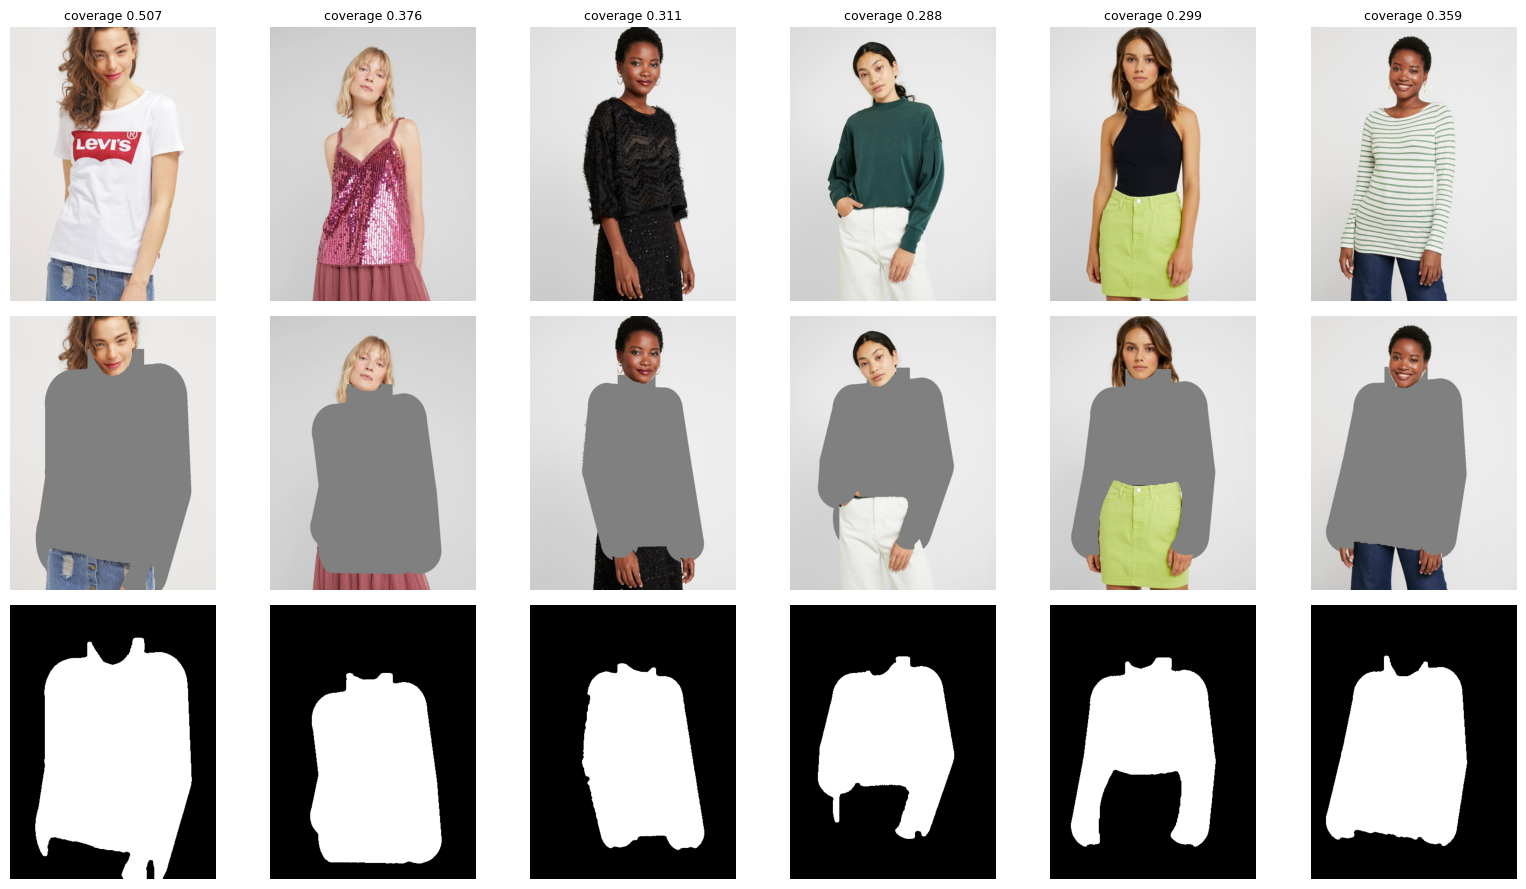

In [14]:
import matplotlib.pyplot as plt

from src.vton import DataConfig, build_agnostic_mask, mask_coverage

DATA = DataConfig()          # 512x384, ngưỡng 12, kernel 9
print(f"latent {DATA.latent_height}x{DATA.latent_width}, pil size {DATA.pil_size}")

fig, axes = plt.subplots(3, 6, figsize=(16, 9))
for column in range(6):
    sample = dataset[column * 1900]
    mask = build_agnostic_mask(
        sample["image"], sample["agnostic"], DATA.pil_size,
        DATA.mask_diff_threshold, DATA.mask_morph_kernel,
    )
    axes[0, column].imshow(sample["image"].resize(DATA.pil_size))
    axes[1, column].imshow(sample["agnostic"].resize(DATA.pil_size))
    axes[2, column].imshow(mask, cmap="gray")
    axes[0, column].set_title(f"coverage {mask_coverage(mask):.3f}", fontsize=9)
    for row in range(3):
        axes[row, column].axis("off")
plt.tight_layout()
plt.show()

In [15]:
# Cổng chặn 1 — hiệu chuẩn theo phân phối đo được, không theo con số phỏng đoán.
import numpy as np
from src.vton import build_agnostic_mask, mask_coverage, mask_vertical_extent

masks = [build_agnostic_mask(dataset[i]["image"], dataset[i]["agnostic"], DATA.pil_size,
                             DATA.mask_diff_threshold, DATA.mask_morph_kernel)
         for i in range(0, 2000, 10)]
cov = np.array([mask_coverage(m) for m in masks])
top = np.array([mask_vertical_extent(m)[0] for m in masks])
# Quần nằm ở 1/3 giữa của 1/4 khung dưới — đây mới là chỗ mask không được lấn.
y0, x0, x1 = int(.75 * DATA.height), int(.33 * DATA.width), int(.67 * DATA.width)
trousers = np.array([m[y0:, x0:x1].mean() for m in masks])

print(f"coverage   med {np.median(cov):.3f}  p05 {np.quantile(cov,.05):.3f}  p95 {np.quantile(cov,.95):.3f}")
print(f"mép trên   med {np.median(top):.3f}")
print(f"vùng quần  med {np.median(trousers):.3f}  p95 {np.quantile(trousers,.95):.3f}\n")

failed = False
for label, rate in {
    "mask rỗng (cov < 0.12)":            (cov < 0.12).mean(),
    "mask nuốt cả khung (cov > 0.70)":   (cov > 0.70).mean(),
    "mask ăn lên đầu (mép trên < 0.05)": (top < 0.05).mean(),
    "mask lấn quần (vùng quần > 0.80)":  (trousers > 0.80).mean(),
}.items():
    ok = rate < 0.05
    failed |= not ok
    print(f"  {'OK  ' if ok else 'FAIL'}  {label:36s} {rate:5.1%}")

assert not failed, (
    "Đường ống mask hỏng thật — xem lưới ảnh cell trên. Lưu ý: coverage cao MỘT MÌNH "
    "không phải lỗi, agnostic-v3.2 vốn sơn rộng."
)
print("\nCỔNG CHẶN 1 ĐẠT")

coverage   med 0.349  p05 0.232  p95 0.536
mép trên   med 0.197
vùng quần  med 0.079  p95 0.580

  OK    mask rỗng (cov < 0.12)                0.0%
  OK    mask nuốt cả khung (cov > 0.70)       0.0%
  OK    mask ăn lên đầu (mép trên < 0.05)     1.0%
  OK    mask lấn quần (vùng quần > 0.80)      0.0%

CỔNG CHẶN 1 ĐẠT


## 5. Embedding rỗng cho F_θ

Try-on giao nhánh prompt cho quần áo, nên text encoder chỉ còn một việc: sinh hằng số này.

> Phải lấy từ **`stabilityai/sd-turbo`** — đó là text encoder mà `InverseModel` được
> huấn luyện cùng. Lấy nhầm từ SD 2.1-base sẽ ra tensor trông hợp lệ nhưng làm giảm
> chất lượng inversion một cách âm thầm. Script đã tự cảnh báo nếu bạn đổi `--model`.

In [16]:
run("python scripts/make_null_embedding.py --output outputs/null_embedding.pt")

import torch

print("shape:", tuple(torch.load("outputs/null_embedding.pt").shape))

$ python scripts/make_null_embedding.py --output outputs/null_embedding.pt
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
INFO __main__: saved outputs/null_embedding.pt with shape (1, 77, 1024)
shape: (1, 77, 1024)


## 6. Cổng chặn 2 — overfit 8 mẫu

Cache 8 mẫu rồi train 400 step. Loss **phải** tụt gần về 0. Không tụt nghĩa là có bug
trong đường ống (mask sai chỗ, token nối nhầm, tham số không nhận gradient) —
**không phải** thiếu dữ liệu. Rẻ hơn nhiều so với phát hiện sau 6 giờ A100.

In [17]:
run("python scripts/build_vton_cache.py --limit 8 --batch-size 4 --output outputs/smoke_cache")

$ python scripts/build_vton_cache.py --limit 8 --batch-size 4 --output outputs/smoke_cache
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
INFO datasets: TensorFlow version 2.20.0 available.
INFO datasets: JAX version 0.7.2 available.
INFO __main__: loaded 8 samples from forgeml/viton_hd
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`

In [18]:
# --eval-every 100: mặc định là 1000, lớn hơn cả max-steps 400, nên validation sẽ không
# chạy lần nào và log kết thúc bằng "best val loss inf".
run("python scripts/train_vton_stage1.py"
    " --cache outputs/smoke_cache"
    " --batch-size 4 --gradient-accumulation-steps 1"
    " --max-steps 400 --log-every 25 --eval-every 100 --preview-every 200"
    " --num-workers 0"
    " --output-dir outputs/smoke_run")

$ python scripts/train_vton_stage1.py --cache outputs/smoke_cache --batch-size 4 --gradient-accumulation-steps 1 --max-steps 400 --log-every 25 --eval-every 100 --preview-every 200 --num-workers 0 --output-dir outputs/smoke_run
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
INFO __main__: cache holds 8 samples
INFO src.vton.trainer: mixed precision auto-selected: bf16
INFO __main__: effective batch size: 4
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be remov

Đọc dòng log cuối. Cần thấy:

- `trainable parameters: ~33 M` — nếu ra hàng trăm M là đã lỡ mở đóng băng G.
- `loss` giảm đều và về gần 0.

Nếu loss đứng yên, dừng lại và soát: token có tách đúng ở vị trí 257 không, mask latent
có phải nhị phân không, `conv_in` đã mở lên 9 kênh chưa.

step 400, tham số trainable 31.89 M
loss step 25: 1.64211  ->  step 400: 0.19053   (giảm 8.6 lần)


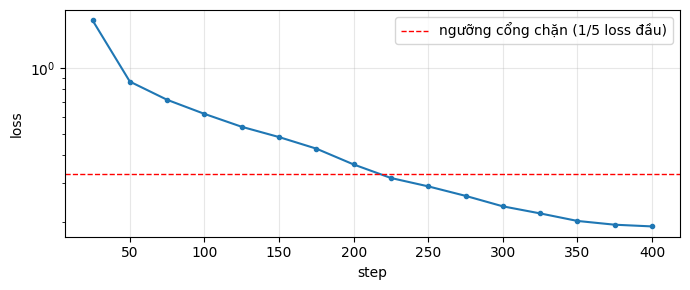


CỔNG CHẶN 2 ĐẠT
Lưu ý: loss KHÔNG về 0 là bình thường — G đóng băng nên có sàn memorize (~0.15). Đó là mốc tham chiếu cho run đầy đủ, đừng kỳ vọng thấp hơn nhiều.
Giờ MỞ outputs/smoke_run/preview_final.png: đã overfit hơn 200 epoch nên hàng giữa phải gần trùng hàng dưới. Không trùng là có bug mà loss không hé lộ.


In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

checkpoints = sorted(Path("outputs/smoke_run").glob("*.pt"), key=lambda p: p.stat().st_mtime)
if not checkpoints:
    raise FileNotFoundError(
        "outputs/smoke_run không có checkpoint nào — cell train phía trên chưa chạy xong "
        "hoặc đã fail. Đọc lỗi ở đó trước, đừng sửa cell này."
    )

ckpt = torch.load(checkpoints[-1], map_location="cpu")
trainable = sum(t.numel() for group in ckpt["weights"].values() for t in group.values())
history = ckpt["loss_history"]

if not history:
    raise RuntimeError(
        "checkpoint không có loss_history — nó được ghi bởi bản trainer cũ. "
        "Chạy lại cell train ở trên."
    )

(first_step, first_loss), (last_step, last_loss) = history[0], history[-1]
print(f"step {ckpt['step']}, tham số trainable {trainable / 1e6:.2f} M")
print(f"loss step {first_step}: {first_loss:.5f}  ->  step {last_step}: {last_loss:.5f}"
      f"   (giảm {first_loss / last_loss:.1f} lần)")

steps, losses = zip(*history)
plt.figure(figsize=(7, 3))
plt.plot(steps, losses, marker="o", markersize=3)
plt.axhline(first_loss / 5, ls="--", c="r", lw=1, label="ngưỡng cổng chặn (1/5 loss đầu)")
plt.xlabel("step"); plt.ylabel("loss"); plt.yscale("log"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

assert 25e6 < trainable < 60e6, "số tham số trainable không đúng kỳ vọng ~33 M"
assert last_loss < first_loss / 5, (
    f"loss chỉ giảm {first_loss / last_loss:.1f} lần trên 8 mẫu qua {last_step} step. "
    "Đường ống có bug: soát token có tách đúng ở 257 không, mask latent có nhị phân "
    "không, conv_in đã mở 9 kênh chưa."
)

print("\nCỔNG CHẶN 2 ĐẠT")
print(
    "Lưu ý: loss KHÔNG về 0 là bình thường — G đóng băng nên có sàn memorize (~0.15). "
    "Đó là mốc tham chiếu cho run đầy đủ, đừng kỳ vọng thấp hơn nhiều.\n"
    "Giờ MỞ outputs/smoke_run/preview_final.png: đã overfit hơn 200 epoch nên hàng giữa "
    "phải gần trùng hàng dưới. Không trùng là có bug mà loss không hé lộ."
)

## 7. Cache đầy đủ

Mọi module Stage 1 đóng băng — F_θ, VAE, DINOv2, CLIP — đều nhận input cố định, nên chạy
một lần rồi cache. Vòng lặp train sau đó bỏ hẳn được một lượt UNet và ~1.7 GB VRAM.

Cache ghi ra thư mục `.npy` memmap: file DINOv2 6 GB không cần nằm vừa RAM.

In [20]:
run("python scripts/build_vton_cache.py --output outputs/vton_cache --batch-size 8")

!du -sh outputs/vton_cache && ls -la outputs/vton_cache

$ python scripts/build_vton_cache.py --output outputs/vton_cache --batch-size 8
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
INFO datasets: TensorFlow version 2.20.0 available.
INFO datasets: JAX version 0.7.2 available.
INFO __main__: loaded 11647 samples from forgeml/viton_hd
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  war

In [21]:
from src.vton import CachedVtonDataset

cache = CachedVtonDataset("outputs/vton_cache")
print(f"{len(cache)} mẫu")
for name, tensor in cache[0].items():
    print(f"  {name:20s} {tuple(tensor.shape)}  {tensor.dtype}")

11647 mẫu
  z_person             (4, 64, 48)  torch.float16
  z_agnostic           (4, 64, 48)  torch.float16
  inverted_noise       (4, 64, 48)  torch.float16
  mask_latent          (1, 64, 48)  torch.float16
  clip_image_embeds    (1024,)  torch.float16
  garment_features     (257, 1024)  torch.float16


## 8. Train Stage 1

Checkpoint chỉ lưu ~33 M tensor trainable (≈130 MB) chứ không lưu 1.76 B tham số đóng
băng — quan trọng vì Colab hay đứt phiên và checkpoint phải ghi ra Drive thật nhanh.

> **Bị đứt giữa chừng thì chỉ cần chạy lại cell train.** Nó tự dò checkpoint mới nhất
> trong `RUN_DIR` và truyền `--resume`, nên chạy lại bao nhiêu lần cũng không mất tiến độ.
> Dòng in đầu tiên nói rõ nó đang `TIẾP TỤC` hay `BẮT ĐẦU MỚI` — đọc dòng đó trước khi
> để nó chạy tiếp vài giờ.

In [22]:
VRAM_GB = int(subprocess.check_output(
    ["nvidia-smi", "--query-gpu=memory.total", "--format=csv,noheader,nounits"]
).decode().split()[0]) / 1024

# Trọng số + optimizer chiếm ~4.2 GB cố định (G fp32 3.7 GB, trainable + Adam 0.5 GB);
# phần còn lại là activation, ~1.5 GB mỗi mẫu khi bật gradient checkpointing.
if VRAM_GB >= 70:
    BATCH_SIZE, ACCUM = 32, 1
elif VRAM_GB >= 38:
    BATCH_SIZE, ACCUM = 16, 1
elif VRAM_GB >= 20:
    BATCH_SIZE, ACCUM = 8, 2
else:
    BATCH_SIZE, ACCUM = 4, 4

EFFECTIVE = BATCH_SIZE * ACCUM
print(f"VRAM {VRAM_GB:.0f} GB -> batch_size={BATCH_SIZE}, accumulation={ACCUM} "
      f"(effective {EFFECTIVE})")
print(f"40,000 step sẽ thấy {40000 * EFFECTIVE:,} mẫu = {40000 * EFFECTIVE / 11647:.0f} epoch")

# Lần chạy trước cell này bị sửa tay thành 1,1 trên A100 80 GB: 40k step chỉ ra 3.4 epoch
# thay vì 55, và log chỉ báo "4.28 steps/s" nên trông vẫn bình thường. Chốt lại ở đây.
assert EFFECTIVE >= 8, (
    f"effective batch {EFFECTIVE} quá nhỏ — gradient sẽ rất nhiễu và số epoch tụt thẳng. "
    "Chỉ hạ xuống dưới 8 khi thật sự OOM, và khi đó tăng ACCUM chứ đừng hạ EFFECTIVE."
)
if VRAM_GB >= 70 and EFFECTIVE < 16:
    raise AssertionError(f"{VRAM_GB:.0f} GB mà effective batch chỉ {EFFECTIVE} — đang phí GPU")

VRAM 80 GB -> batch_size=32, accumulation=1 (effective 32)
40,000 step sẽ thấy 1,280,000 mẫu = 110 epoch


In [ ]:
from pathlib import Path

RUN_DIR = "/content/drive/MyDrive/Fast_VTON_stage1"
MAX_STEPS = 40000

Path(RUN_DIR).mkdir(parents=True, exist_ok=True)

# Cell này tự nối tiếp. Colab đứt phiên là chuyện bình thường, nên chạy lại nó bao nhiêu
# lần cũng an toàn: có checkpoint thì --resume, không thì chạy mới. Trước đây chỗ này là
# hai cell, cell resume bị comment sẵn — quên bỏ comment là train lại từ step 0, mất hàng
# giờ và ghi đè final.pt.
# Chọn theo thời gian ghi vì "final.pt" < "step_*.pt" theo alphabet.
found = sorted(Path(RUN_DIR).glob("*.pt"), key=lambda p: p.stat().st_mtime)
resume = f" --resume {shlex.quote(str(found[-1]))}" if found else ""
print(f"TIẾP TỤC từ {found[-1].name}" if found else f"BẮT ĐẦU MỚI (chưa có .pt trong {RUN_DIR})")

# Muốn chạy hẳn từ đầu: đổi RUN_DIR sang thư mục khác. Đừng xoá thư mục cũ — nó là bản
# lưu duy nhất của mấy giờ đã train.
run(f"python scripts/train_vton_stage1.py"
    f" --cache outputs/vton_cache"
    f" --batch-size {BATCH_SIZE}"
    f" --gradient-accumulation-steps {ACCUM}"
    f" --max-steps {MAX_STEPS}"
    f" --output-dir {shlex.quote(RUN_DIR)}"
    f" --num-workers 2"
    + resume)

BẮT ĐẦU MỚI (chưa có .pt trong /content/drive/MyDrive/Fast_VTON_stage1)
$ python scripts/train_vton_stage1.py --cache outputs/vton_cache --batch-size 32 --gradient-accumulation-steps 1 --max-steps 40000 --output-dir /content/drive/MyDrive/Fast_VTON_stage1 --num-workers 2
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
INFO __main__: cache holds 11647 samples
INFO src.vton.trainer: mixed precision auto-selected: bf16
INFO __main__: effective batch size: 32
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: 

### Xem ảnh preview

Vòng lặp train ghi `preview_XXXXXX.png` vào `RUN_DIR` mỗi `--preview-every` step. Mỗi ảnh
là ba hàng: **agnostic đầu vào — model dự đoán — ảnh thật**.

Đây là thứ đã thiếu ở lần chạy trước. Toàn bộ đánh giá khi đó là một số MSE trong không gian
latent, nên không ai biết output có ra hình người mặc áo hay không, và lỗi batch-size sống
sót suốt 2.6 giờ. **Nhìn ảnh trước khi tin loss.**

In [ ]:
from pathlib import Path

from IPython.display import Image as ShowImage
from IPython.display import display

previews = sorted(Path(RUN_DIR).glob("preview_*.png"))
print(f"{len(previews)} ảnh preview")
for path in previews[-3:]:                      # ba mốc gần nhất
    print(path.name)
    display(ShowImage(filename=str(path)))

## 9. Kiểm tra G không bị đụng

Nguyên tắc cốt lõi của Stage 1: generator đóng băng. Chỉ `attn2.to_k/to_v` và `conv_in`
được phép đổi. Kiểm chứng bằng chính công cụ đã dùng để chứng minh tác giả đóng băng G.

In [ ]:
run("python scripts/dissect_checkpoints.py --compare-generator")

## 10. Đóng gói toàn bộ model thành 1 file → Google Drive

`export_bundle` ghi **một** file chứa mọi module cần cho inference cộng config để dựng
lại chúng: generator (đã mở 9 kênh) + garment encoder + mạng nghịch đảo + VAE + CLIP
vision + embedding rỗng. Máy đích **không cần** tải Hugging Face, **không cần**
`weights/`, chỉ cần file này.

Vì sao là bundle state-dict chứ không phải `torch.save(model)`: pickle một module sống sẽ
ghi lại đường dẫn class của từng submodule, nên file chết ngay khi có ai đổi tên class —
đúng thứ mà refactor làm. Bundle chỉ chứa tensor và config nên sống sót.

Kích thước fp16: khoảng **4.9 GB** (~2.46 B tham số).

In [ ]:
from pathlib import Path

import torch

from src.constants import INPAINTING_LATENT_CHANNELS
from src.models import AuxiliaryModel, InverseModel, IPSBV2Model
from src.vton import CheckpointConfig, GarmentEncoder, Stage1Config, Stage1Trainer

CHECKPOINTS = CheckpointConfig()
config = Stage1Config(output_dir=Path(RUN_DIR), max_steps=MAX_STEPS)

aux_model = AuxiliaryModel(device="cuda", load_text_encoder=False)
generator = IPSBV2Model(
    CHECKPOINTS.generator_dir,
    CHECKPOINTS.ip_adapter_path,
    aux_model,
    device="cuda",
    with_ip_mask_controller=True,
    inpainting_channels=INPAINTING_LATENT_CHANNELS,
)
garment_encoder = GarmentEncoder(CHECKPOINTS.garment_backbone).to("cuda")
inverse_model = InverseModel(CHECKPOINTS.inversion_dir, device="cuda", load_text_encoder=False)

# Nạp trọng số đã train vào bộ khung vừa dựng.
trainer = Stage1Trainer(generator, garment_encoder, config)
# final.pt < step_*.pt theo alphabet, nên chọn theo thời gian ghi.
trainer.load_checkpoint(max(Path(RUN_DIR).glob("*.pt"), key=lambda p: p.stat().st_mtime))
print("đã nạp checkpoint tại step", trainer.state.step)

In [ ]:
from src.vton import CachedVtonDataset, export_bundle

BUNDLE_PATH = "/content/drive/MyDrive/Fast_VTON_stage1/Fast_VTON_full.pt"

# Đọc từ chính cache đã train, đừng gõ tay: sai số này thì lúc inference chuỗi token
# quần áo đổi độ dài dưới chân cross-attention mà không báo lỗi gì.
GARMENT_RES = CachedVtonDataset("outputs/vton_cache").garment_resolution
print("garment_resolution của cache:", GARMENT_RES)

export_bundle(
    BUNDLE_PATH,
    generator=generator,
    garment_encoder=garment_encoder,
    inverse_model=inverse_model,
    step=trainer.state.step,
    height=config.data.height,
    width=config.data.width,
    garment_resolution=GARMENT_RES,
    include_frozen=True,        # tự chứa: máy đích không cần tải gì thêm
    dtype="fp16",
    null_embedding=torch.load("outputs/null_embedding.pt"),
)

In [ ]:
from src.vton import bundle_summary

summary = bundle_summary(BUNDLE_PATH)
print(f"file: {summary['file_size_bytes'] / 1e9:.2f} GB")
print(f"tổng tham số: {summary['total_parameters'] / 1e6:.1f} M\n")
for group, count in sorted(summary["parameters_by_group"].items()):
    print(f"  {group:18s} {count / 1e6:9.2f} M")
print("\nmanifest:")
for key, value in summary["manifest"].items():
    if not key.endswith("_config"):
        print(f"  {key:22s} {value}")

### Kiểm tra bundle nạp lại được

Chạy trên chính Colab để chắc file không hỏng trước khi mang về server 3090.

In [ ]:
import gc

# Giải phóng VRAM trước khi dựng lại từ bundle.
del generator, garment_encoder, inverse_model, aux_model, trainer
gc.collect()
torch.cuda.empty_cache()

from src.vton import load_bundle

bundle = load_bundle(BUNDLE_PATH, device="cuda")
print("step:", bundle.manifest.step)
print("độ phân giải:", bundle.manifest.height, "x", bundle.manifest.width)
print("kênh conv_in:", bundle.manifest.inpainting_channels)
print("có module đóng băng:", bundle.manifest.includes_frozen)
print("mạng nghịch đảo:", type(bundle.inversion_unet).__name__)
print("VAE:", type(bundle.vae).__name__)
print("\nBundle nạp lại thành công")

## Xong

`Fast_VTON_full.pt` đã nằm trên Drive. Trên server RTX 3090 chỉ cần:

```python
from src.vton import load_bundle

bundle = load_bundle("Fast_VTON_full.pt", device="cuda")
```

fp16 toàn bộ chiếm khoảng 3.2 GB VRAM — thoải mái trong 24 GB.

**Việc còn lại (Stage 2, xem mục 2.10 của `docs/VTON_PLAN.md`)**

- Mở F_θ (865.91 M), thêm DISTS + `L_regu` kiểu SDS theo Eq. 8 của paper.
- Bật `DataConfig.horizontal_flip` và cache cả hai chiều.
- **Ablation bỏ F_θ:** thay `inverted_noise` bằng nhiễu Gauss rồi đo lại. Nếu chất lượng
  tụt không đáng kể thì bỏ hẳn F_θ — inference còn một lượt UNet, nhanh gấp đôi. Đây là
  quyết định đáng giá nhất còn lại, và phải đo chứ không đoán.

In [ ]:
from google.colab import drive

# Ép Drive ghi hết buffer rồi unmount. Chắc chắn hơn sleep(60): nó chặn tới khi ghi xong
# thật, còn 60 giây là con số đoán — bundle 4.9 GB có thể chưa flush kịp.
# Sau cell này Drive không truy cập được nữa; cần dùng lại thì drive.mount() lần nữa.
drive.flush_and_unmount()
print("Đã flush Google Drive. Chạy cell dưới để trả runtime.")

In [ ]:
# Trả runtime: ngắt kết nối, giải phóng GPU, dừng đốt compute unit.
# Hàm đúng là unassign() — không có google.colab.runtime.disconnect_all().
from google.colab import runtime

runtime.unassign()